# Хинчагов Руслан 2 группа ДПО "Инженирия искусственного интелекта"
## 8-9 Домашняя работа

In [2]:
import random 
import numpy as np
import torch
import os
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import pandas as pd 
import json

SEED = 42 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch_ver:', torch.__version__)

device: cpu
torch_ver: 2.8.0


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

test_ds = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

class_names = train_full.classes 
print('classes:', class_names)
print('train size:', len(train_full))
print('test size', len(test_ds))

classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train size: 50000
test size 10000


In [4]:
BATCH_SIZE = 256 if device.type == 'cuda' else 64 
NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.25
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda')
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda')
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda')
)

x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [5]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [6]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 3*32*32,
        hidden_dims: tuple[int, ...] = (512, 256, 128),
        num_classes: int = 10, 
        activation: str = 'relu',
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        
        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Неизвестная функция активации: {activation}")
        
        layers = [nn.Flatten()]
        
        prev = input_dim
        
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if use_batchnorm:
                layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)
    
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)


logits: torch.Size([64, 10])


In [7]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()



def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_acc = 0 
    n_batches = 0
    
    for x, y in loader:
        x = x.to(device, non_blocking = True)
        y = y.to(device, non_blocking = True)
        
        optimizer.zero_grad(set_to_none=True)
        
        logits = model(x)
        loss = criterion(logits, y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    
    for x,y in loader:
        x = x.to(device, non_blocking = True)
        y = y.to(device, non_blocking = True)
        
        logits = model(x)
        loss = criterion(logits, y)
        
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
        
    return total_loss / n_batches, total_acc / n_batches        

In [8]:
def plot_history(hist: tuple[int, ...], title="", save_path=None):
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    if save_path:
        plt.savefig(save_path)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    
    if save_path: 
        plt.savefig(save_path.replace('.png', '_acc.png'))
    
    
    plt.show()

In [9]:
def fit (
    model, 
    train_loader, 
    val_loader,
    optimizer, 
    criterion, 
    device, 
    epochs: int = 10, 
    early_stopping=None,
    verbose: bool = False,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0
    best_state_dict = None
    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
    
        
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state_dict = model.state_dict().copy()
            
        
        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )
            
        if best_state_dict is not None:
            model.load_state_dict(best_state_dict)
            torch.save(best_state_dict, 'artifacts/best_model.pt')
        
        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break
        
    return history, best_val_acc

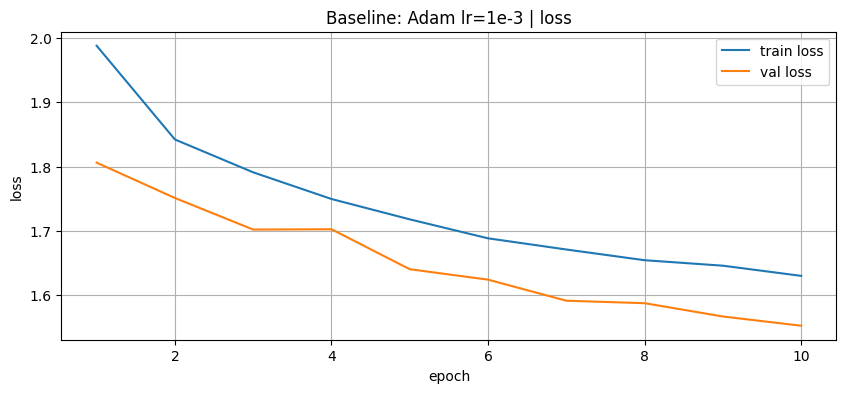

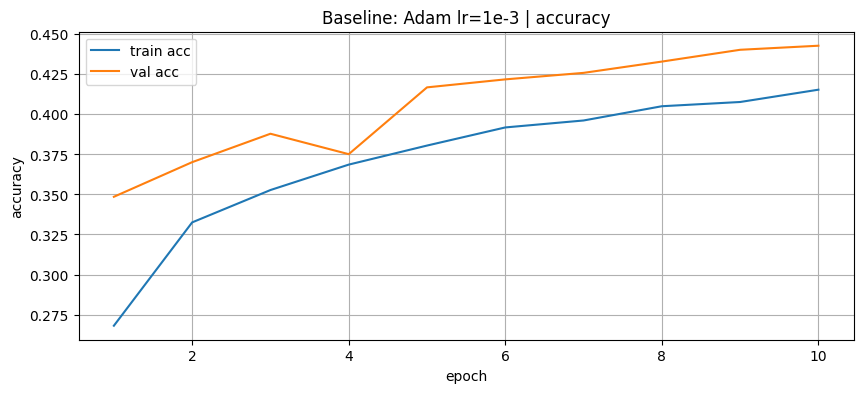

In [10]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 10

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

baseline_opt = make_optimizer(model, kind="adam", lr=1e-3, weight_decay=0.0)

baseline_hist, _ = fit(model, train_loader, val_loader, baseline_opt, criterion, device, epochs=EPOCHS)
plot_history(baseline_hist, title="Baseline: Adam lr=1e-3")

In [11]:
experiments = []
results_df = pd.DataFrame(columns=['experiment_id', 'dataset', 'seed', 'model_summary', 
                                   'optimizer', 'lr', 'momentum', 'weight_decay', 
                                   'epochs_trained', 'best_val_accuracy', 'best_val_loss'])

def run_exp(experiment_id, 
            hidden_dims, 
            lr: float=1e-3, 
            optimizer='Adam',
            momentum = 0, 
            weight_decay = 0,
            epochs = 10, 
            dropout_p = 0.0, 
            use_batchnorm=False,
            early_stopping=None 
            ):
    
    global results_df 
    
    torch.manual_seed(SEED)
    
    model = MLP(input_dim=3*32*32, hidden_dims=hidden_dims, dropout_p=dropout_p, use_batchnorm=use_batchnorm)
    
    optimize_obj = make_optimizer(model, optimizer, lr)
    criterion = nn.CrossEntropyLoss()
    
    
    history, best_acc = fit(model, train_loader, val_loader, optimize_obj, criterion, device, epochs=epochs, verbose=True, early_stopping=early_stopping)


    best_val_loss = min(history['val_loss']) if 'val_loss' in history else 0
    
    new_result = {
        'experiment_id': experiment_id,
        'dataset': 'CIFAR10',
        'seed': SEED,
        'model_summary': f"hidden={hidden_dims}/ReLU/d={dropout_p}/BN={use_batchnorm}",
        'optimizer': optimizer.upper(),
        'lr': lr,
        'momentum': momentum,
        'weight_decay': weight_decay,
        'epochs_trained': epochs,
        'best_val_accuracy': best_acc,
        'best_val_loss': best_val_loss
    }

    
    results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
        
    plot_history(history,title=f"{experiment_id}: lr={lr}", save_path=f"artifacts/figures/{experiment_id}.png")
    
    return history, results_df

epoch 01/10 | train loss=1.8908, acc=0.3127 | val loss=1.7475, acc=0.3715
epoch 02/10 | train loss=1.7093, acc=0.3847 | val loss=1.6723, acc=0.3954
epoch 03/10 | train loss=1.6282, acc=0.4175 | val loss=1.6272, acc=0.4147
epoch 04/10 | train loss=1.5743, acc=0.4381 | val loss=1.5829, acc=0.4340
epoch 05/10 | train loss=1.5296, acc=0.4551 | val loss=1.5593, acc=0.4362
epoch 06/10 | train loss=1.5065, acc=0.4628 | val loss=1.5030, acc=0.4669
epoch 07/10 | train loss=1.4692, acc=0.4740 | val loss=1.4870, acc=0.4700
epoch 08/10 | train loss=1.4458, acc=0.4805 | val loss=1.5212, acc=0.4555
epoch 09/10 | train loss=1.4270, acc=0.4878 | val loss=1.4914, acc=0.4709
epoch 10/10 | train loss=1.4017, acc=0.4968 | val loss=1.4793, acc=0.4725


/var/folders/r6/yd7rf7xx7yvfbgk45dzmbs1h0000gn/T/ipykernel_927/4129789810.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)


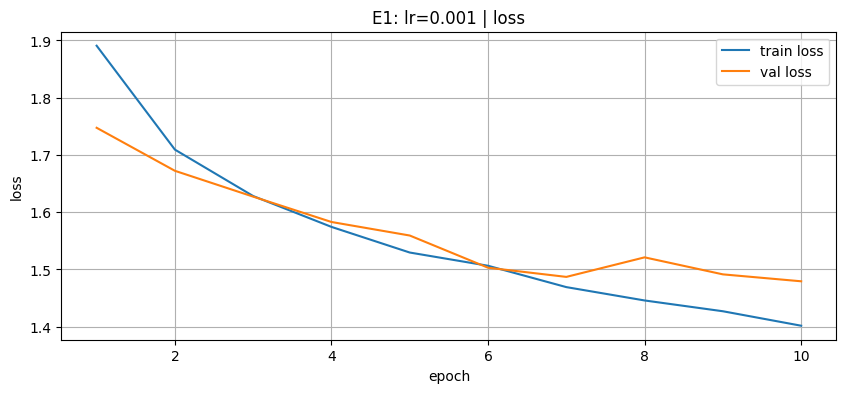

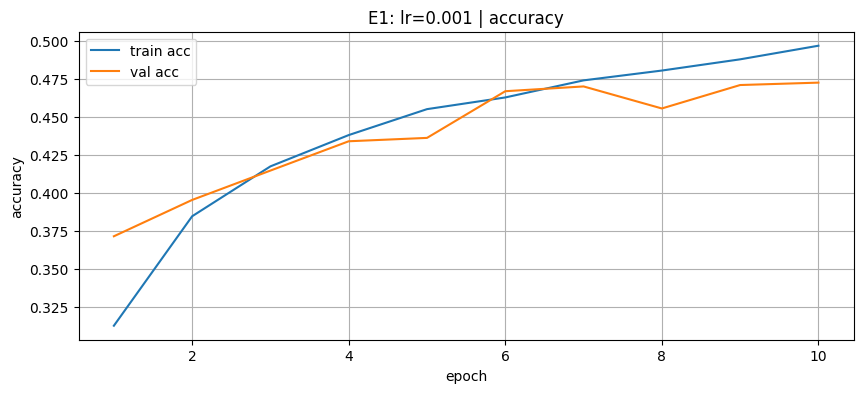

epoch 01/10 | train loss=1.9947, acc=0.2619 | val loss=1.8693, acc=0.3151
epoch 02/10 | train loss=1.8556, acc=0.3240 | val loss=1.7924, acc=0.3411
epoch 03/10 | train loss=1.7960, acc=0.3483 | val loss=1.7110, acc=0.3879
epoch 04/10 | train loss=1.7607, acc=0.3642 | val loss=1.6943, acc=0.3978
epoch 05/10 | train loss=1.7274, acc=0.3763 | val loss=1.6773, acc=0.3887
epoch 06/10 | train loss=1.7049, acc=0.3844 | val loss=1.6430, acc=0.4106
epoch 07/10 | train loss=1.6879, acc=0.3893 | val loss=1.5997, acc=0.4258
epoch 08/10 | train loss=1.6630, acc=0.3989 | val loss=1.5984, acc=0.4319
epoch 09/10 | train loss=1.6532, acc=0.4020 | val loss=1.5711, acc=0.4292
epoch 10/10 | train loss=1.6455, acc=0.4071 | val loss=1.5780, acc=0.4358


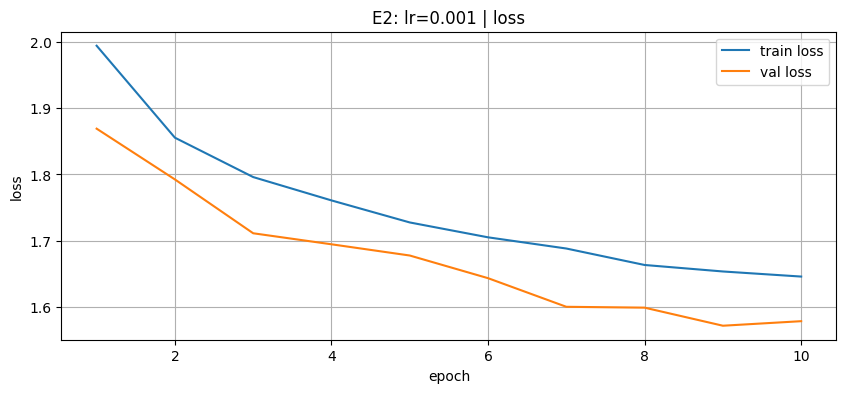

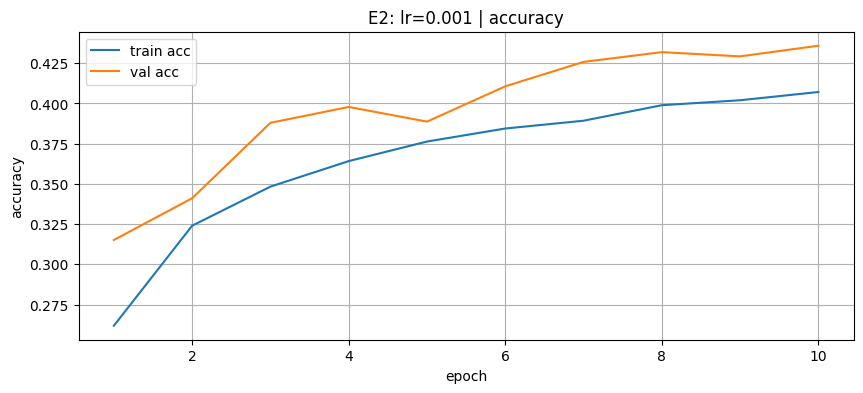

epoch 01/10 | train loss=1.9818, acc=0.2716 | val loss=1.8073, acc=0.3520
epoch 02/10 | train loss=1.8186, acc=0.3426 | val loss=1.7323, acc=0.3809
epoch 03/10 | train loss=1.7536, acc=0.3710 | val loss=1.6893, acc=0.3907
epoch 04/10 | train loss=1.7079, acc=0.3889 | val loss=1.6185, acc=0.4272
epoch 05/10 | train loss=1.6699, acc=0.4039 | val loss=1.6006, acc=0.4321
epoch 06/10 | train loss=1.6401, acc=0.4156 | val loss=1.5698, acc=0.4565
epoch 07/10 | train loss=1.6158, acc=0.4225 | val loss=1.5453, acc=0.4528
epoch 08/10 | train loss=1.5945, acc=0.4311 | val loss=1.5191, acc=0.4629
epoch 09/10 | train loss=1.5755, acc=0.4351 | val loss=1.4932, acc=0.4641
epoch 10/10 | train loss=1.5516, acc=0.4464 | val loss=1.5034, acc=0.4612


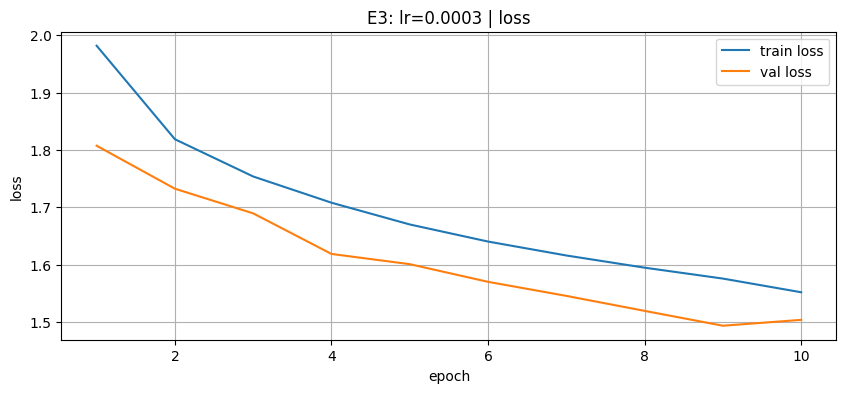

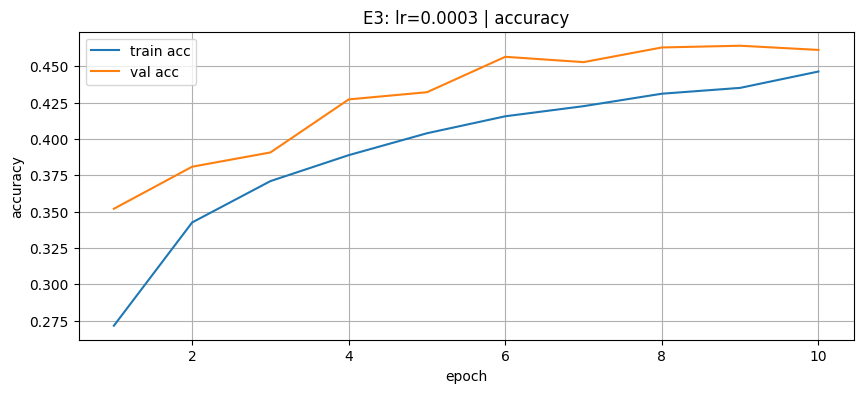

epoch 01/10 | train loss=2.0322, acc=0.2401 | val loss=1.8898, acc=0.3139
epoch 02/10 | train loss=1.8714, acc=0.3195 | val loss=1.7945, acc=0.3464
epoch 03/10 | train loss=1.8127, acc=0.3445 | val loss=1.7298, acc=0.3828
epoch 04/10 | train loss=1.7735, acc=0.3629 | val loss=1.6746, acc=0.4066
epoch 05/10 | train loss=1.7463, acc=0.3711 | val loss=1.6319, acc=0.4151
epoch 06/10 | train loss=1.7097, acc=0.3854 | val loss=1.6125, acc=0.4271
epoch 07/10 | train loss=1.6887, acc=0.3944 | val loss=1.6057, acc=0.4280
epoch 08/10 | train loss=1.6640, acc=0.4027 | val loss=1.5755, acc=0.4376
epoch 09/10 | train loss=1.6443, acc=0.4100 | val loss=1.5646, acc=0.4389
epoch 10/10 | train loss=1.6342, acc=0.4111 | val loss=1.5606, acc=0.4446


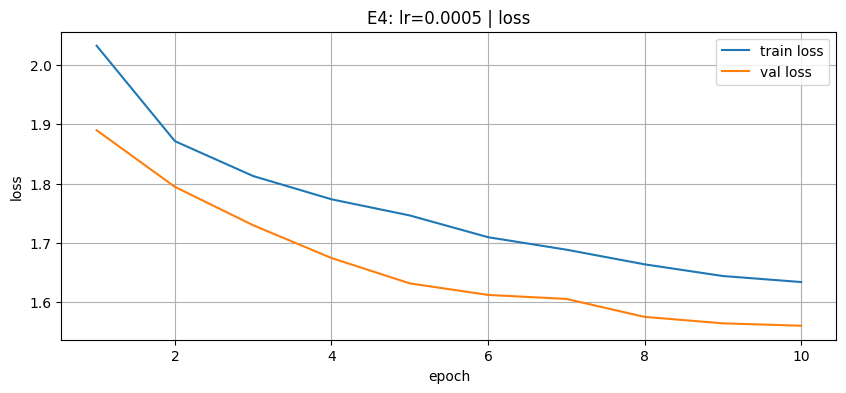

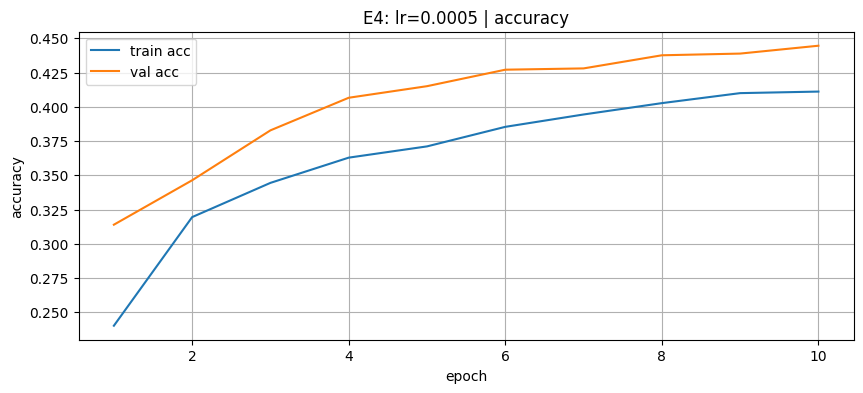

In [12]:
histories = {}
histories['E1'], results_df = run_exp('E1',hidden_dims=(256, 128))
histories['E2'], results_df = run_exp('E2', (512, 256, 128), dropout_p=0.2)
histories['E3'], results_df = run_exp('E3', (512, 256), lr=3e-4, dropout_p=0.3, use_batchnorm=True)
histories['E4'], results_df = run_exp('E4', (512, 256, 128), lr=5e-4, dropout_p=0.3, use_batchnorm=True, early_stopping=EarlyStopping(patience=5, min_delta=0.001))


epoch 01/10 | train loss=18.0394, acc=0.0986 | val loss=2.3067, acc=0.1001
epoch 02/10 | train loss=2.3089, acc=0.0989 | val loss=2.3098, acc=0.1017
epoch 03/10 | train loss=2.3106, acc=0.1024 | val loss=2.3098, acc=0.1004
epoch 04/10 | train loss=2.3104, acc=0.1000 | val loss=2.3176, acc=0.1033
epoch 05/10 | train loss=2.3114, acc=0.0998 | val loss=2.3198, acc=0.0972
epoch 06/10 | train loss=2.3116, acc=0.0999 | val loss=2.3114, acc=0.1003
epoch 07/10 | train loss=2.3115, acc=0.0991 | val loss=2.3271, acc=0.0966
epoch 08/10 | train loss=2.3115, acc=0.1022 | val loss=2.3076, acc=0.1005
epoch 09/10 | train loss=2.3113, acc=0.1005 | val loss=2.3089, acc=0.1011
epoch 10/10 | train loss=2.3114, acc=0.1019 | val loss=2.3074, acc=0.1031


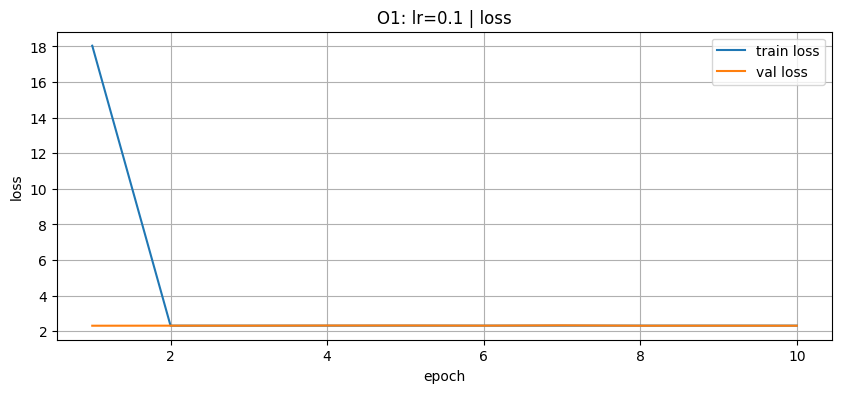

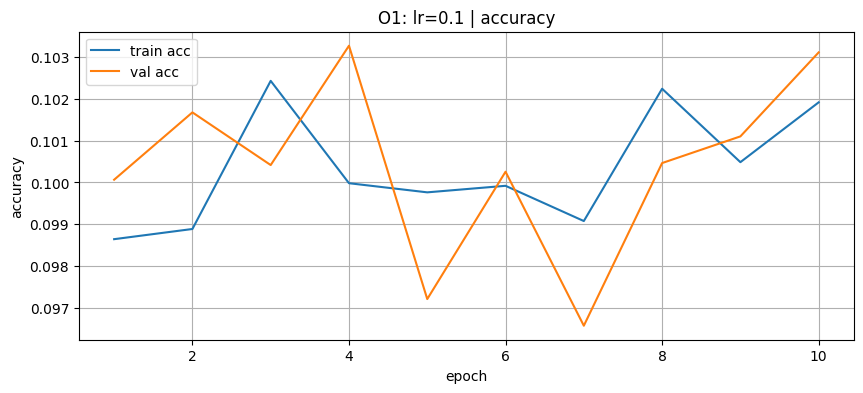

epoch 01/10 | train loss=2.1206, acc=0.2600 | val loss=2.0090, acc=0.3055
epoch 02/10 | train loss=1.9595, acc=0.3260 | val loss=1.9201, acc=0.3439
epoch 03/10 | train loss=1.8961, acc=0.3469 | val loss=1.8695, acc=0.3514
epoch 04/10 | train loss=1.8569, acc=0.3582 | val loss=1.8380, acc=0.3648
epoch 05/10 | train loss=1.8296, acc=0.3689 | val loss=1.8165, acc=0.3663
epoch 06/10 | train loss=1.8070, acc=0.3763 | val loss=1.7937, acc=0.3766
epoch 07/10 | train loss=1.7874, acc=0.3842 | val loss=1.7750, acc=0.3835
epoch 08/10 | train loss=1.7704, acc=0.3882 | val loss=1.7596, acc=0.3866
epoch 09/10 | train loss=1.7547, acc=0.3943 | val loss=1.7469, acc=0.3929
epoch 10/10 | train loss=1.7395, acc=0.4011 | val loss=1.7328, acc=0.3968


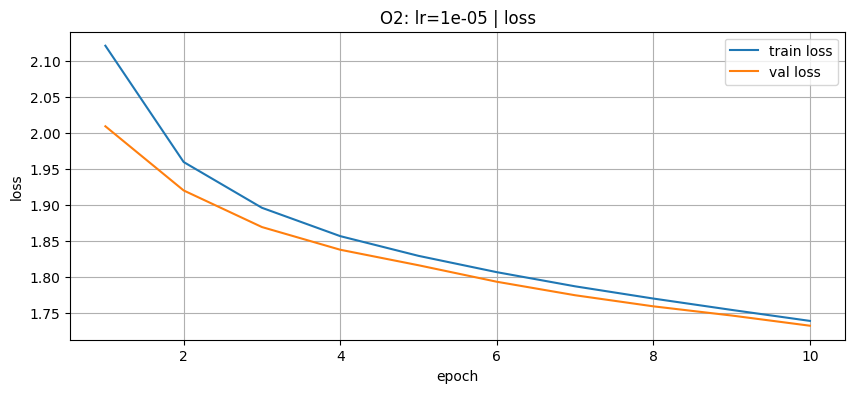

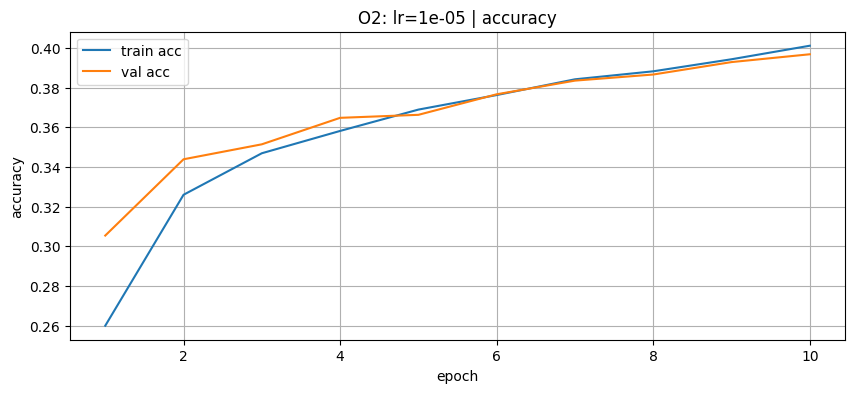

epoch 01/10 | train loss=1.8942, acc=0.3115 | val loss=1.7539, acc=0.3638
epoch 02/10 | train loss=1.7170, acc=0.3849 | val loss=1.6928, acc=0.3959
epoch 03/10 | train loss=1.6645, acc=0.4064 | val loss=1.6332, acc=0.4192
epoch 04/10 | train loss=1.6161, acc=0.4246 | val loss=1.5742, acc=0.4407
epoch 05/10 | train loss=1.5721, acc=0.4408 | val loss=1.5808, acc=0.4441
epoch 06/10 | train loss=1.5500, acc=0.4484 | val loss=1.5319, acc=0.4535
epoch 07/10 | train loss=1.5163, acc=0.4603 | val loss=1.5333, acc=0.4562
epoch 08/10 | train loss=1.4968, acc=0.4683 | val loss=1.5030, acc=0.4685
epoch 09/10 | train loss=1.4761, acc=0.4761 | val loss=1.5437, acc=0.4457
epoch 10/10 | train loss=1.4471, acc=0.4878 | val loss=1.5068, acc=0.4692


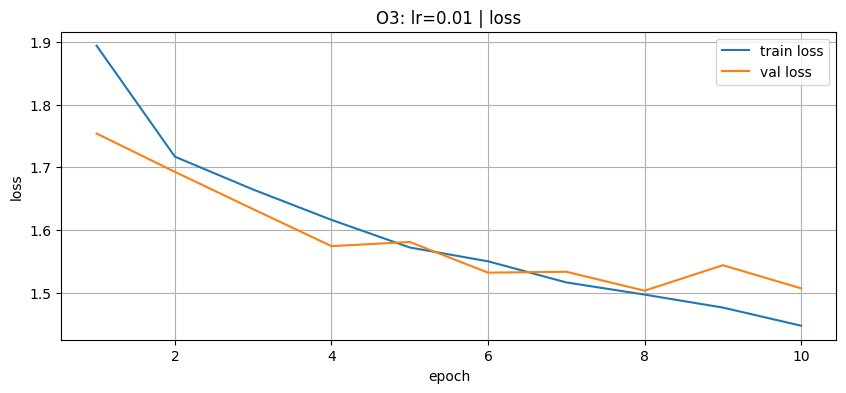

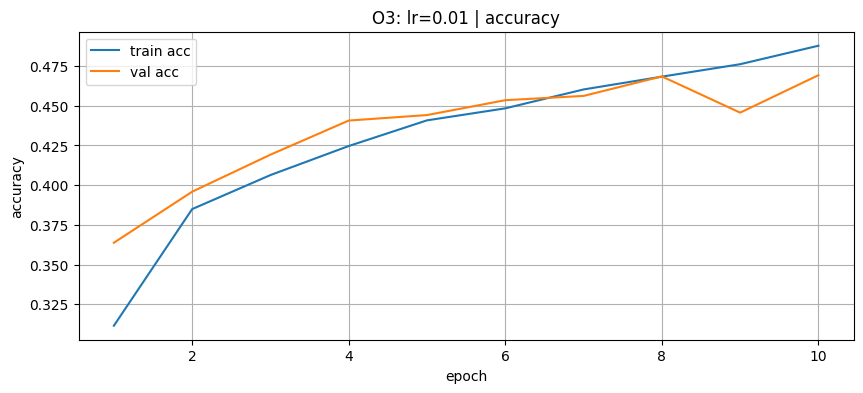

In [13]:
histories["O1"] = run_exp('O1', (512,), lr=1e-1)
histories["O2"] = run_exp('O2',(512,), lr=1e-5)
histories["O3"] = run_exp('O3',(512,), optimizer='SGD', weight_decay=1e-4, lr=1e-2, momentum=0.9)

In [14]:

results_df.to_csv('artifacts/runs.csv')
best_exp = results_df.loc[results_df['best_val_accuracy'].idxmax()]
best_config = {
    'dataset': 'CIFAR10', 
    'seed': SEED,
    'model': {'expirement_id': best_exp['experiment_id'],'input_dim': 3072, 'hidden_dims': eval(best_exp['model_summary'].split('/')[0][7:]), 
              'dropout_p': 0.3, 'use_batchnorm': True},
    'optimizer': {'type': 'Adam', 'lr': float(best_exp['lr'])},
    'best_val_accuracy': float(best_exp['best_val_accuracy'])
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

In [15]:
print(results_df)

  experiment_id  dataset seed                               model_summary  \
0            E1  CIFAR10   42       hidden=(256, 128)/ReLU/d=0.0/BN=False   
1            E2  CIFAR10   42  hidden=(512, 256, 128)/ReLU/d=0.2/BN=False   
2            E3  CIFAR10   42        hidden=(512, 256)/ReLU/d=0.3/BN=True   
3            E4  CIFAR10   42   hidden=(512, 256, 128)/ReLU/d=0.3/BN=True   
4            O1  CIFAR10   42           hidden=(512,)/ReLU/d=0.0/BN=False   
5            O2  CIFAR10   42           hidden=(512,)/ReLU/d=0.0/BN=False   
6            O3  CIFAR10   42           hidden=(512,)/ReLU/d=0.0/BN=False   

  optimizer       lr momentum weight_decay epochs_trained  best_val_accuracy  \
0      ADAM  0.00100        0            0             10           0.472513   
1      ADAM  0.00100        0            0             10           0.435842   
2      ADAM  0.00030        0            0             10           0.464110   
3      ADAM  0.00050        0            0             10      

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

o1_data = histories["O1"][0]
epochs1 = range(1, len(o1_data["train_loss"]) + 1)
o2_data = histories["O2"][0]
epochs2 = range(1, len(o2_data["train_loss"]) + 1)

ax1.plot(epochs1, o1_data["train_loss"], label='Train loss O1')
ax1.plot(epochs1, o1_data["val_loss"], label='Value loss O1')
ax1.set_title("Reasonable LR (O1)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs2, o2_data["train_loss"], label="Train loss O2")
ax2.plot(epochs2, o2_data["val_loss"], label="Value loss 02")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle("Train/Val Loss for LR extremes O1 vs O2")
plt.tight_layout()

plt.savefig("./artifacts/figures/curves_lr_extremes.png")
plt.close()